In [ ]:
# If you're not a student, RUNTIME --> CHANGE RUNTIME TYPE --> T4 GPU
# Or, if you're a student , RUNTIME --> CHANGE RUNTIME TYPE --> ? --> purchase one of our paid plans HERE --> Colab Pro for Education --> Use A100 GPU

#!/usr/bin/env python3
import urllib.request
# URLs for the zip file
links = [
    'https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz',
]
for idx, link in enumerate(links):
    fn = 'images_%02d.tar.gz' % (idx+1)
    print('downloading'+fn+'...')
    urllib.request.urlretrieve(link, fn)  # download the zip file
print("Download complete. Please check the checksums")

downloadingimages_01.tar.gz...
Download complete. Please check the checksums


In [ ]:
import tarfile
for idx in range(len(links)):
    fn = 'images_%02d.tar.gz' % (idx+1)
    print('extracting ' + fn + '...')
    with tarfile.open(fn, 'r:gz') as tar:
        tar.extractall(path='images')  # extracts into "images" folder
print("Extraction complete.")

extracting images_01.tar.gz...


/tmp/ipykernel_468/4181125251.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='images')  # extracts into "images" folder


Extraction complete.


In [ ]:
import os
for root, dirs, files in os.walk('images'):
    print("DIR:", root)
    print("Subdirs:", dirs)
    print("Files:", files[:5])  # just preview
    print()

DIR: images
Subdirs: ['images']
Files: []

DIR: images/images
Subdirs: []
Files: ['00000240_000.png', '00000820_011.png', '00001059_001.png', '00000211_026.png', '00000143_004.png']



In [ ]:
image_dir = 'images'
image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')
count = 0
for root, dirs, files in os.walk(image_dir):
    for file in files:
        if file.lower().endswith(image_extensions):
            count += 1
print("Total number of images:", count)

import pandas as pd
df = pd.read_csv("/Data_Entry_2017_v2020.csv")
df.head()

Total number of images: 4999


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 1: Data Cleaning and Preprocessing
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Clean metadata
df = df.copy()
df = df.dropna(subset=['Image Index', 'Finding Labels'])
df = df.drop_duplicates(subset=['Image Index'])

# Binary label
df['label'] = df['Finding Labels'].apply(lambda x: 0 if str(x).strip() == 'No Finding' else 1)

# Full image path
def find_image_path(filename, image_dir='images'):
    for root, dirs, files in os.walk(image_dir):
        if filename in files:
            return os.path.join(root, filename)
    return None

df['image_path'] = df['Image Index'].apply(find_image_path)
df = df.dropna(subset=['image_path']).reset_index(drop=True)

print("Rows after cleaning and matching:", len(df))
print(df['label'].value_counts())

MAX_SAMPLES = 5000
if len(df) > MAX_SAMPLES:
    df, _ = train_test_split(
        df,
        train_size=MAX_SAMPLES,
        stratify=df['label'],
        random_state=42
    )

# Split
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# Preprocessing
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
])

def make_dataset(dataframe, training=False):
    paths = dataframe['image_path'].values
    labels = dataframe['label'].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(len(dataframe), seed=42)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df, training=False)

print("Datasets created successfully.")

Rows after cleaning and matching: 4999
label
0    2754
1    2245
Name: count, dtype: int64
Train: 3499
Validation: 750
Test: 750
Datasets created successfully.


# Step 2

In [ ]:
# Step 2: Modeling Methodology
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121

In [ ]:
# DenseNet model creation
from tensorflow.keras.applications import DenseNet121

def build_densenet():
    base_model = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
    )
    return model
densenet_model = build_densenet()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# EfficientNet model creation

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.efficientnet import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_efficientnet():
    base_model = EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model
efficientnet_model = build_efficientnet()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Equally weight normal/abnormal classes to eliminate bias
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y = train_df["label"].values
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y
)
class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

print(class_weights)

{0: np.float64(0.9074170124481328), 1: np.float64(1.1136218968809675)}


In [ ]:
# DenseNet model training
dn_EPOCHS = 50
history_den = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=dn_EPOCHS,
    class_weight=class_weights
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 92s 478ms/step - accuracy: 0.5250 - auc: 0.5397 - loss: 0.8108 - precision: 0.4756 - recall: 0.5633 - val_accuracy: 0.4760 - val_auc: 0.5239 - val_loss: 0.7950 - val_precision: 0.4581 - val_recall: 0.9080
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.5193 - auc: 0.5547 - loss: 0.7868 - precision: 0.4693 - recall: 0.5404 - val_accuracy: 0.5093 - val_auc: 0.5637 - val_loss: 0.7539 - val_precision: 0.4727 - val_recall: 0.7953
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.5419 - auc: 0.5594 - loss: 0.7917 - precision: 0.4913 - recall: 0.5767 - val_accuracy: 0.5427 - val_auc: 0.5877 - val_loss: 0.7354 - val_precision: 0.4941 - val_recall: 0.7418
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.5470 - auc: 0.5729 - loss: 0.7767 - precision: 0.4961 - recall: 0.5659 - val_accuracy: 0.5533 - val_auc: 0.6075 - val_loss: 0.7266 - val_precision: 0.5021 - val_recall: 0.7122
Epoch 5/50
110/110 ━━━━

In [ ]:
# EfficientNet model training
en_EPOCHS = 15
history_eff = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=en_EPOCHS,
    class_weight=class_weights
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.5047 - auc: 0.5061 - loss: 0.7485 - precision: 0.4529 - recall: 0.4959 - val_accuracy: 0.5507 - val_auc: 0.5025 - val_loss: 0.6915 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.5096 - auc: 0.5021 - loss: 0.7374 - precision: 0.4571 - recall: 0.4914 - val_accuracy: 0.4653 - val_auc: 0.4933 - val_loss: 0.6941 - val_precision: 0.4512 - val_recall: 0.8783
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.5070 - auc: 0.5159 - loss: 0.7183 - precision: 0.4559 - recall: 0.5067 - val_accuracy: 0.4600 - val_auc: 0.5111 - val_loss: 0.6936 - val_precision: 0.4514 - val_recall: 0.9377
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.5139 - auc: 0.5114 - loss: 0.7207 - precision: 0.4620 - recall: 0.5035 - val_accuracy: 0.4600 - val_auc: 0.4566 - val_loss: 0.6941 - val_precision: 0.4506 - val_recall: 0.9199
Epoch 5/15
110/11

# Step 3

In [ ]:
#import dependencies
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

#get predictions

print("1. Generating Predictions...\n")

#DenseNet predictions
y_pred_prob = densenet_model.predict(test_ds).flatten()

#EfficientNet predictions
y_pred_prob_eff = efficientnet_model.predict(test_ds).flatten()

#true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("Predictions generated successfully.")
print(f"Total test samples: {len(y_true)}\n")

#convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)
y_pred_eff = (y_pred_prob_eff > 0.5).astype(int)

#print probabilities
print("Sample DenseNet Probabilities (first 10):")
print(y_pred_prob[:10])

print("\nSample EfficientNet Probabilities (first 10):")
print(y_pred_prob_eff[:10])

print("\nSample True Labels (first 10):")
print(y_true[:10])

#print summary stats
print("\nDenseNet Probability Stats:")
print(f"Min: {np.min(y_pred_prob):.4f}, Max: {np.max(y_pred_prob):.4f}, Mean: {np.mean(y_pred_prob):.4f}")

print("\nEfficientNet Probability Stats:")
print(f"Min: {np.min(y_pred_prob_eff):.4f}, Max: {np.max(y_pred_prob_eff):.4f}, Mean: {np.mean(y_pred_prob_eff):.4f}")

#convert probabilities → binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)
y_pred_eff = (y_pred_prob_eff > 0.5).astype(int)

print("\nBinary prediction sample (DenseNet):")
print(y_pred[:10])

print("\nBinary prediction sample (EfficientNet):")
print(y_pred_eff[:10])


1. Generating Predictions...

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
Predictions generated successfully.
Total test samples: 750

Sample DenseNet Probabilities (first 10):
[0.2351 0.8115 0.8203 0.777  0.1665 0.2015 0.3242 0.4546 0.275  0.2554]

Sample EfficientNet Probabilities (first 10):
[0.496  0.4995 0.499  0.5    0.5005 0.5015 0.509  0.498  0.503  0.503 ]

Sample True Labels (first 10):
[0 0 1 0 0 1 0 0 0 0]

DenseNet Probability Stats:
Min: 0.0560, Max: 0.9360, Mean: 0.4890

EfficientNet Probability Stats:
Min: 0.4741, Max: 0.5205, Mean: 0.5024

Binary prediction sample (DenseNet):
[0 1 1 1 0 0 0 0 0 0]

Binary prediction sample (EfficientNet):
[0 0 0 0 1 1 1 0 1 1]


DenseNet produces a wide range of predicted probablilites (roughly 0.05 to 0.93), indicating that the model is confident and able to differentiate between normal and abnormal cases. In contrast, EfficientNet predictions are tightly clustered around 0.5, suggesting that the model is uncertain and not effectively learning distinguishing features from the data.


2. Confusion Matrices

DenseNet Confusion Matrix:
[[268 145]
 [114 223]]


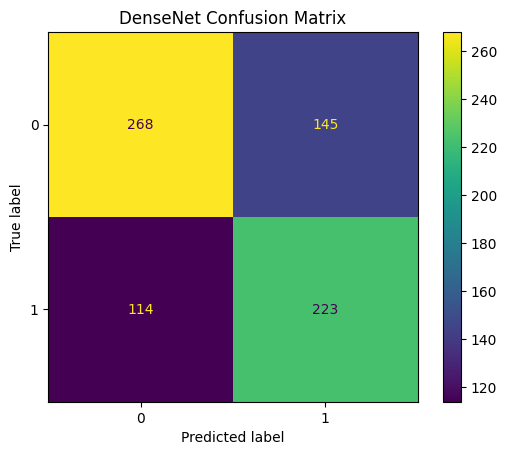


EfficientNet Confusion Matrix:
[[160 253]
 [120 217]]


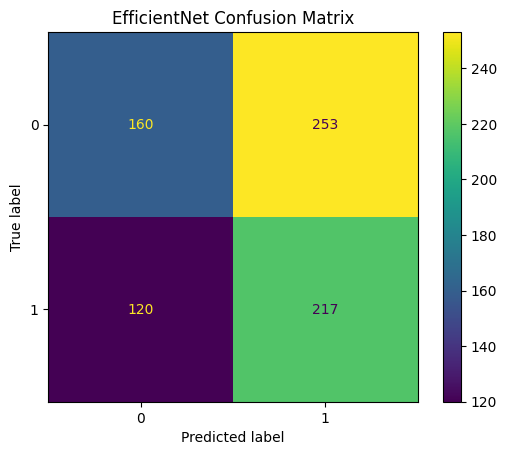

In [ ]:
#confusion matrices

print("\n2. Confusion Matrices\n")

cm_dn = confusion_matrix(y_true, y_pred)
print("DenseNet Confusion Matrix:")
print(cm_dn)

ConfusionMatrixDisplay(cm_dn).plot()
plt.title("DenseNet Confusion Matrix")
plt.show()

cm_eff = confusion_matrix(y_true, y_pred_eff)
print("\nEfficientNet Confusion Matrix:")
print(cm_eff)

ConfusionMatrixDisplay(cm_eff).plot()
plt.title("EfficientNet Confusion Matrix")
plt.show()

DenseNet demonstrates more balanced performance, correctly identifying a substantial number of both normal (true negative) and abnormal (true positive) cases, while maintaining fewer false positives compared to EfficientNet. EfficientNet producer a significantly higher number of false positives, indicating that it frequently misclassifies normal images as abnormal. Although both models have similar recall for abnormal cases, DenseNet provides a more reliable overall classification.

In [ ]:
#classification reports

print("\n3. Classification Reports\n")

print("DenseNet:")
print(classification_report(y_true, y_pred))

print("EfficientNet:")
print(classification_report(y_true, y_pred_eff))


3. Classification Reports

DenseNet:
              precision    recall  f1-score   support

           0       0.70      0.65      0.67       413
           1       0.61      0.66      0.63       337

    accuracy                           0.65       750
   macro avg       0.65      0.66      0.65       750
weighted avg       0.66      0.65      0.66       750

EfficientNet:
              precision    recall  f1-score   support

           0       0.57      0.39      0.46       413
           1       0.46      0.64      0.54       337

    accuracy                           0.50       750
   macro avg       0.52      0.52      0.50       750
weighted avg       0.52      0.50      0.50       750



DenseNet achieves higher overall accuracy (~65%) and maintains a balanced tradeoff between precision and recall. Importantly, it achieves a recall of approximately 66% for abnormal cases, aligning with the project goal of prioritizing detection of abnormalities. EfficientNet performs near random (50% accuracy), with low precision for abnormal cases, indicating that many of its positive predictions are incorrect. This reinforces that DenseNet is the more effective model.


4. ROC Curve Analysis

DenseNet AUC: 0.6927
EfficientNet AUC: 0.5056


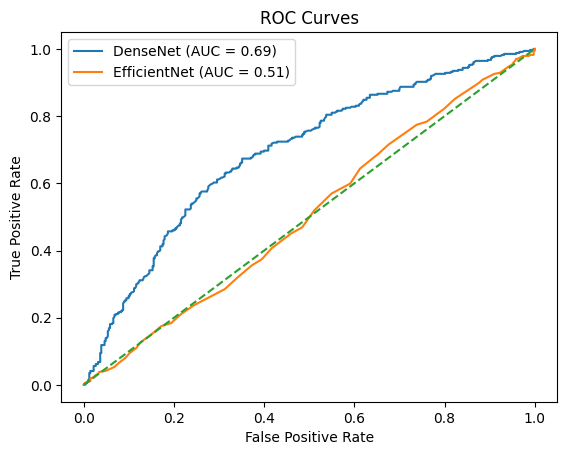

In [ ]:
#roc curves
print("\n4. ROC Curve Analysis\n")

fpr_dn, tpr_dn, _ = roc_curve(y_true, y_pred_prob)
roc_auc_dn = auc(fpr_dn, tpr_dn)

fpr_eff, tpr_eff, _ = roc_curve(y_true, y_pred_prob_eff)
roc_auc_eff = auc(fpr_eff, tpr_eff)

print(f"DenseNet AUC: {roc_auc_dn:.4f}")
print(f"EfficientNet AUC: {roc_auc_eff:.4f}")

plt.plot(fpr_dn, tpr_dn, label=f"DenseNet (AUC = {roc_auc_dn:.2f})")
plt.plot(fpr_eff, tpr_eff, label=f"EfficientNet (AUC = {roc_auc_eff:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

The ROC curve further confirms the performance difference between the models.DenseNet achieves an AUC of approximately 0.69, indicating meaningful ability to distinguish between normal and abnormal images across classification thresholds. In contrast, EfficientNet achieves an AUC of approximately 0.51, which is effectively equivalent to random guessing, confirming that it does not learn useful patterns from the data.


5. Prediction Distributions



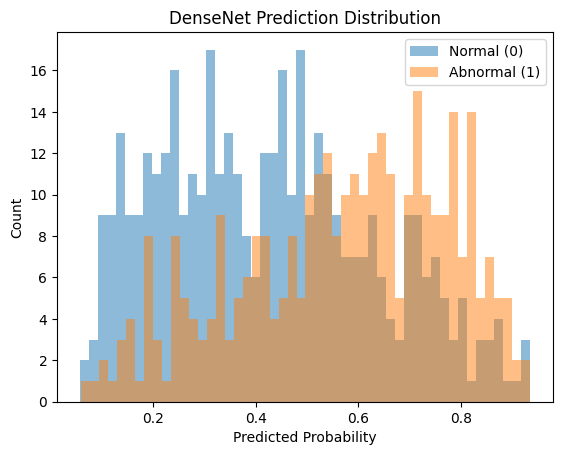

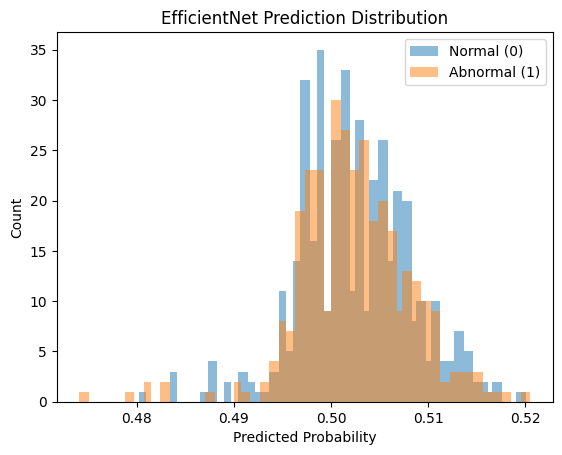

In [ ]:
#prediction distributions

print("\n5. Prediction Distributions\n")

plt.hist(y_pred_prob[y_true == 0], bins=50, alpha=0.5, label="Normal (0)")
plt.hist(y_pred_prob[y_true == 1], bins=50, alpha=0.5, label="Abnormal (1)")
plt.legend()
plt.title("DenseNet Prediction Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

plt.hist(y_pred_prob_eff[y_true == 0], bins=50, alpha=0.5, label="Normal (0)")
plt.hist(y_pred_prob_eff[y_true == 1], bins=50, alpha=0.5, label="Abnormal (1)")
plt.legend()
plt.title("EfficientNet Prediction Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

DenseNet produces a broad distribution of predicted probabilities, with normal cases concentrated at lower values and abnormal cases at higher values. This separation indicates that the model has learned meaningful distintions between the two classes, despite some overlap. In contrast, EfficientNet predictions are tightly clustered around 0.5 for both classes, showing almost no separation and confirming that the model is unable to effectively differentiate between normal and abnormal x-rays.

# Graphs

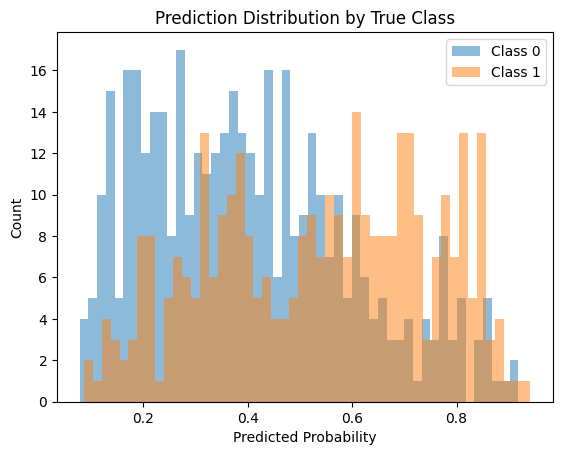

In [ ]:
import matplotlib.pyplot as plt

y_pred_prob = y_pred_prob.flatten()

plt.hist(y_pred_prob[y_true == 0], bins=50, alpha=0.5, label="Class 0")
plt.hist(y_pred_prob[y_true == 1], bins=50, alpha=0.5, label="Class 1")

plt.legend()
plt.title("Prediction Distribution by True Class, DenseNet")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

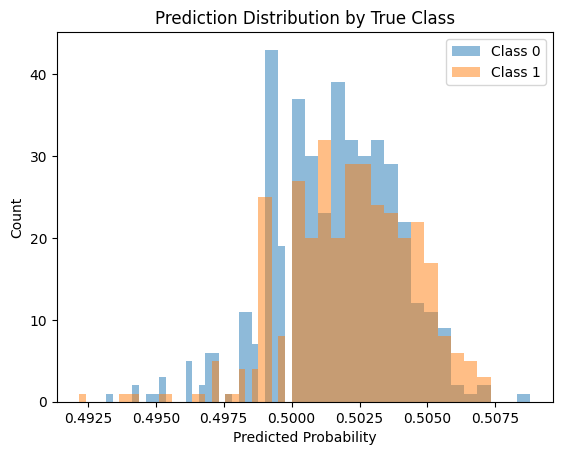

In [ ]:
import matplotlib.pyplot as plt

y_pred_prob_eff = y_pred_prob_eff.flatten()

plt.hist(y_pred_prob_eff[y_true == 0], bins=50, alpha=0.5, label="Class 0")
plt.hist(y_pred_prob_eff[y_true == 1], bins=50, alpha=0.5, label="Class 1")

plt.legend()
plt.title("Prediction Distribution by True Class, EfficientNet")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

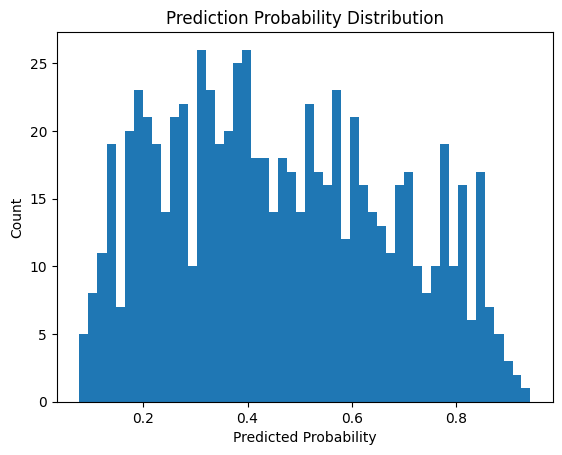

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y_pred_prob, bins=50)
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

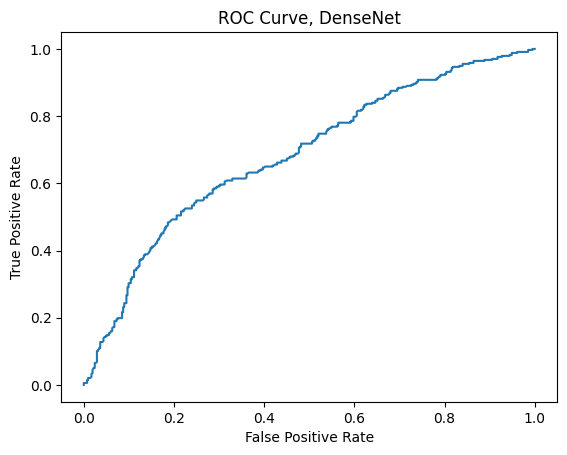

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve, DenseNet")
plt.show()

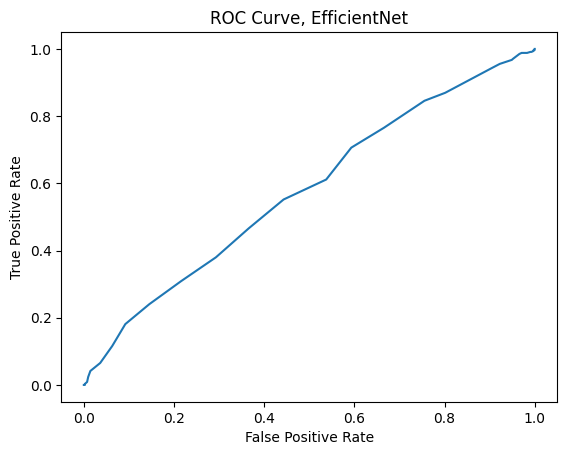

In [ ]:
fpr_eff, tpr_eff, thresholds_eff = roc_curve(y_true_eff, y_pred_prob_eff)

plt.plot(fpr_eff, tpr_eff)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve, EfficientNet")
plt.show()